# =========================
# Импорт библиотек
# =========================

In [13]:
import os
# Фикс краша LightGBM на macOS ARM (M1/M2/M3) — ограничиваем потоки OpenMP
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report
)

from lightautoml.automl.presets.tabular_presets import TabularAutoML
from lightautoml.tasks import Task
import kagglehub

# =========================
# Загрузка датасета
# =========================

# Загрузка и описание датасета

В данной работе используется датасет **Hotel Reservations Classification Dataset**, содержащий информацию о бронированиях отелей.  
Основная задача — построить модель бинарной классификации, которая будет предсказывать, будет ли бронирование отменено клиентом.

## Целевая переменная

- `booking_status` — статус бронирования:
  - `Canceled` — бронирование было отменено
  - `Not_Canceled` — бронирование не было отменено

---

# Описание признаков

| Колонка | Описание |
|---|---|
| `Booking_ID` | Уникальный идентификатор бронирования |
| `no_of_adults` | Количество взрослых гостей |
| `no_of_children` | Количество детей |
| `no_of_weekend_nights` | Количество ночей на выходных |
| `no_of_week_nights` | Количество ночей в будние дни |
| `type_of_meal_plan` | Тип выбранного плана питания |
| `required_car_parking_space` | Требуется ли парковочное место |
| `room_type_reserved` | Тип забронированного номера |
| `lead_time` | Количество дней между бронированием и заездом |
| `arrival_year` | Год прибытия |
| `arrival_month` | Месяц прибытия |
| `arrival_date` | День прибытия |
| `market_segment_type` | Тип сегмента клиента |
| `repeated_guest` | Является ли клиент постоянным |
| `no_of_previous_cancellations` | Количество предыдущих отмен |
| `no_of_previous_bookings_not_canceled` | Количество предыдущих успешных бронирований |
| `avg_price_per_room` | Средняя стоимость комнаты |
| `no_of_special_requests` | Количество специальных запросов клиента |
| `booking_status` | Статус бронирования (целевая переменная) |

---

# Постановка задачи

Необходимо обучить модель машинного обучения с использованием библиотеки **LightAutoML**, которая сможет автоматически анализировать табличные данные и предсказывать вероятность отмены бронирования.

В процессе работы выполняются:
- загрузка и анализ датасета;
- разделение данных на обучающую и тестовую выборки;
- автоматическое обучение модели с помощью LightAutoML;
- оценка качества модели с использованием метрик классификации;
- анализ важности признаков.

In [14]:
path = kagglehub.dataset_download(
    "ahsan81/hotel-reservations-classification-dataset"
)

print("Dataset path:", path)
files = os.listdir(path)

print(files)
csv_file = [f for f in files if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))
df.head()
df.info()

Dataset path: /Users/nikitabaslykov/.cache/kagglehub/datasets/ahsan81/hotel-reservations-classification-dataset/versions/1
['Hotel Reservations.csv']
<class 'pandas.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  str    
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  str    
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  str    
 8   lead_time                             36275 non-null  int64  
 9   arrival_ye

# =========================
# Подготовка данных
# =========================

In [15]:
TARGET = 'booking_status'
# перевод target в 0/1
df[TARGET] = df[TARGET].map({
    'Not_Canceled': 0,
    'Canceled': 1
})

df.dropna(subset=[TARGET], inplace=True)

train, test = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df[TARGET]
)


# =========================
# LightAutoML
# =========================

In [16]:
task = Task('binary')
automl = TabularAutoML(
    task=task,
    timeout=600,
    cpu_limit=1,  # 1 поток — фикс SIGSEGV OpenMP на macOS ARM
    general_params={'use_algos': [['lgb']]}
)


# обучение
oof_pred = automl.fit_predict(
    train,
    roles={'target': TARGET}
)

# =========================
# Предсказания
# =========================

In [17]:
pred = automl.predict(test)
# вероятности
proba = pred.data[:, 0]
# бинарные предсказания
y_pred = (proba > 0.5).astype(int)
y_true = test[TARGET].values


# =========================
# Метрики
# =========================

In [18]:
acc = accuracy_score(y_true, y_pred)
roc = roc_auc_score(y_true, proba)
print(f'Accuracy: {acc:.4f}')
print(f'ROC-AUC: {roc:.4f}')
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

Accuracy: 0.8853
ROC-AUC: 0.9477

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4878
           1       0.86      0.78      0.82      2377

    accuracy                           0.89      7255
   macro avg       0.88      0.86      0.87      7255
weighted avg       0.88      0.89      0.88      7255



# =========================
# Feature Importance
# =========================


Top Features (% от суммарной важности):

                             Feature  Importance
                           lead_time   36.123887
                  avg_price_per_room   22.843226
              no_of_special_requests    9.779724
                       arrival_month    9.390763
                        arrival_date    7.550680
                   no_of_week_nights    3.577594
                no_of_weekend_nights    3.338462
                        arrival_year    2.885717
                        no_of_adults    2.720099
          required_car_parking_space    0.936823
                      no_of_children    0.411198
                      repeated_guest    0.285210
no_of_previous_bookings_not_canceled    0.149480
        no_of_previous_cancellations    0.007139


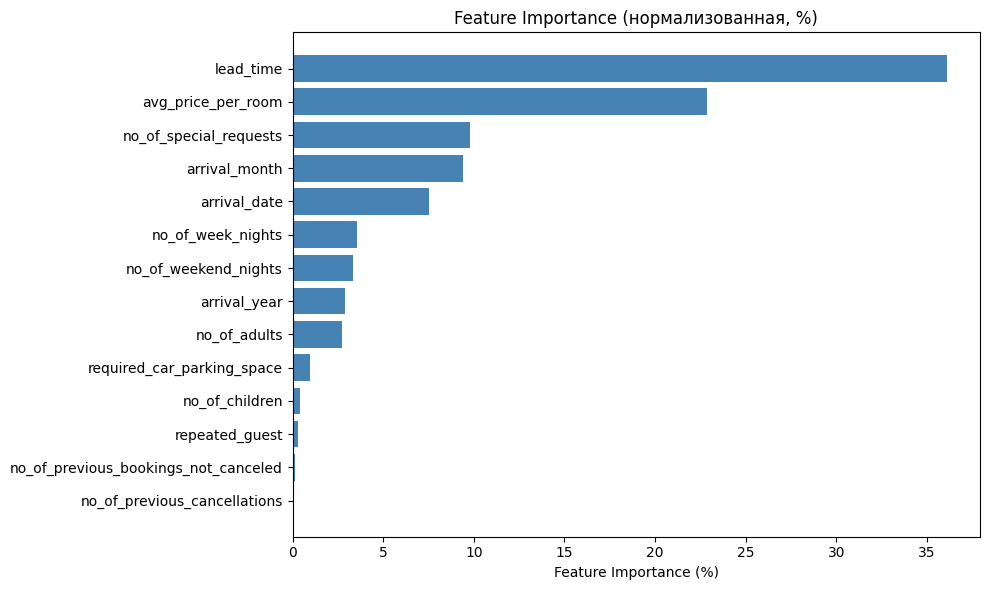

In [19]:
fi = automl.get_feature_scores()
# Нормализация: переводим в проценты от суммы
fi['Importance'] = fi['Importance'] / fi['Importance'].sum() * 100
fi = fi.sort_values('Importance', ascending=False).reset_index(drop=True)
print("\nTop Features (% от суммарной важности):\n")
print(fi.to_string(index=False))
# Визуализация
plt.figure(figsize=(10, 6))
plt.barh(fi['Feature'][::-1], fi['Importance'][::-1], color='steelblue')
plt.xlabel('Feature Importance (%)')
plt.title('Feature Importance (нормализованная, %)')
plt.tight_layout()
plt.show()